In [1]:
%cd ../../

/mnt/Storage/NLP Project/NLP_Group_15


# Feature Engineering and Representation
Splitting the data set in to 80/10/10 for traning, validating, and testing

In [2]:
import os
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import save_npz


In [3]:
tokenized_df = pd.read_csv('data/processed/tokenized_news.csv')

# split: 80% train, 20% for validate and test
train_df, temp_df = train_test_split(
    tokenized_df,
    test_size=0.20,
    stratify=tokenized_df['label'],
    random_state=42
)

# split: split the 20% into 10% validate and 10% test
validate_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(validate_df)}")
print(f"Test size: {len(test_df)}")

print("\nTrain class balance:")
print(train_df['label'].value_counts(normalize=True) * 100)

print("\nValidation class balance:")
print(validate_df['label'].value_counts(normalize=True) * 100)

print("\nTest class balance:")
print(test_df['label'].value_counts(normalize=True) * 100)

Train size: 31059
Validation size: 3882
Test size: 3883

Train class balance:
label
1    53.897421
0    46.102579
Name: proportion, dtype: float64

Validation class balance:
label
1    53.889748
0    46.110252
Name: proportion, dtype: float64

Test class balance:
label
1    53.901622
0    46.098378
Name: proportion, dtype: float64


**Save the splited datasets**

In [4]:
train_df.to_csv('data/processed/train.csv', index=False)
validate_df.to_csv('data/processed/validate.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

**TF-IDF on train.csv**

In [5]:
# Create a TF-IDF vectorizer with 5000 words and including 1 and 2 word terms
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Learn from training text and convert it to numbers
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['content'])

# convert validate and test data to numbers
X_validate_tfidf = tfidf_vectorizer.transform(validate_df['content'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['content'])

print(X_train_tfidf.shape, X_validate_tfidf.shape, X_test_tfidf.shape)

(31059, 5000) (3882, 5000) (3883, 5000)


In [6]:
y_train = train_df['label']
y_validate = validate_df['label']
y_test = test_df['label']

**saving the fitted vectorizer and matrices for reuse**

In [7]:
os.makedirs('data/processed/tfidf', exist_ok=True)
os.makedirs('models/LogReg', exist_ok=True)

joblib.dump(tfidf_vectorizer, 'models/LogReg/tfidf_vectorizer.pkl')

save_npz('data/processed/tfidf/train_tfidf_content.npz', X_train_tfidf)
save_npz('data/processed/tfidf/validate_tfidf_content.npz', X_validate_tfidf)
save_npz('data/processed/tfidf/test_tfidf_content.npz', X_test_tfidf)

# Training Logistic Regression

In [8]:
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pathlib import Path
import matplotlib.pyplot as plt

Traning the Logistic Regression Model and save it.

In [16]:
model_path = Path('models/LogReg/logreg_model.pkl')

if model_path.exists():
    logreg_model = joblib.load(model_path)
else:
    logreg_model = LogisticRegression(max_iter=1000, random_state=42)
    logreg_model.fit(X_train_tfidf, y_train)
    joblib.dump(logreg_model, model_path) # save the model

Evaluating on validation set

In [17]:
y_validate_pred = logreg_model.predict(X_validate_tfidf)

print("Validation Accuracy:", accuracy_score(y_validate, y_validate_pred))
print(classification_report(y_validate, y_validate_pred, target_names=['fake', 'real']))

Validation Accuracy: 0.9829984544049459
              precision    recall  f1-score   support

        fake       0.99      0.97      0.98      1790
        real       0.98      0.99      0.98      2092

    accuracy                           0.98      3882
   macro avg       0.98      0.98      0.98      3882
weighted avg       0.98      0.98      0.98      3882



Confusion matrix on validation set

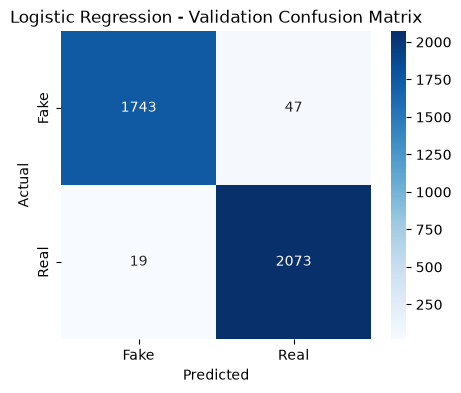

In [18]:
conf_matrix = confusion_matrix(y_validate, y_validate_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Validation Confusion Matrix')
plt.show()